# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).


# Data: Geospatial Data

This notebook prepares geospatial explanatory variables representing the urban environmental context where social activities occur.

This notebook exposes geospatial feature outputs for downstream modelling in-memory via `geo_gdf`, and supports direct export to GeoPackage.

Primary handover fields:
- Index for the location: `id`
- Feature groups: Streetscape Perception (`SP_*`), Functionality (`FC_*`), Accessibility (`AC_*`), Contact Density (`CD_*`)
- Coordinates: `longitude`, `latitude`
- Geometry: `geometry`

Data source used in this notebook:
- `data/data_geospatial.gpkg`


## 1. Geospatial Feature System

We organize geospatial indicators into four dimensions:
- Streetscape Perception (SP)
- Functionality (FC)
- Accessibility (AC)
- Contact Density (CD)

Detailed definitions of subcategories and features are provided in Table 1 of the Supplementary Material. The full set contains 12 subcategories and 41 spatial features.

These features are subsequently merged with social activity variables for UCI modelling and causal analysis.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Read geospatial data
file_path = "./data/data_geospatial.gpkg"
geo_gdf = gpd.read_file(file_path)

# Set CRS if not already correct
geo_gdf.crs = "EPSG:4326"

print(geo_gdf.crs)
print(geo_gdf.columns)

# Choose columns to plot (excluding id, lon, lat, geometry)
columns_to_plot = [col for col in geo_gdf.columns if col not in ['id', 'longitude', 'latitude', 'geometry']]
print(f"Total number of feature columns: {len(columns_to_plot)}")

sp_count = sum(col.startswith('SP') for col in columns_to_plot)
fc_count = sum(col.startswith('FC') for col in columns_to_plot)
ac_count = sum(col.startswith('AC') for col in columns_to_plot)
cd_count = sum(col.startswith('CD') for col in columns_to_plot)

print(f"Number of features in Streetscape Perception (SP) dimension': {sp_count}")
print(f"Number of features in Functionality (FC) dimension: {fc_count}")
print(f"Number of features in Accessibility (AC) dimension: {ac_count}")
print(f"Number of features in Contact Density (CD) dimension: {cd_count}")


EPSG:4326
Index(['id', 'longitude', 'latitude', 'SP_1-E_comfort',
       'SP_2-E_sunshine_intensity', 'SP_3-E_temp_inference',
       'SP_4-E_humidity_inference', 'SP_5-E_wind_inference',
       'SP_6-E_greenery_rate', 'SP_7-E_shading_area', 'SP_8-E_heat_source',
       'SP_9-E_traffic_flow', 'SP_1-D_imageability', 'SP_2-D_enclosure',
       'SP_3-D_human_scale', 'SP_4-D_complexity', 'FC_1-R_eating_rating',
       'FC_1-D_eating_density', 'FC_2-R_retail_rating',
       'FC_2-D_retail_density', 'FC_3-R_life_rating', 'FC_3-D_life_density',
       'FC_4-R_recreation_rating', 'FC_4-D_recreation_density',
       'FC_5-R_health_rating', 'FC_5-D_health_density',
       'FC_6-R_community_rating', 'FC_6-D_community_density',
       'FC_7-R_trans_rating', 'FC_7-D_trans_density', 'FC_1-H_HDB_density',
       'FC_1-G_review_polarity', 'FC_2-G_review_subjectivity',
       'AC_1-L_closeness400', 'AC_2-L_closeness800', 'AC_1-G_closeness2000',
       'AC_2-G_closeness6000', 'AC_1-T_subway_accessibilit

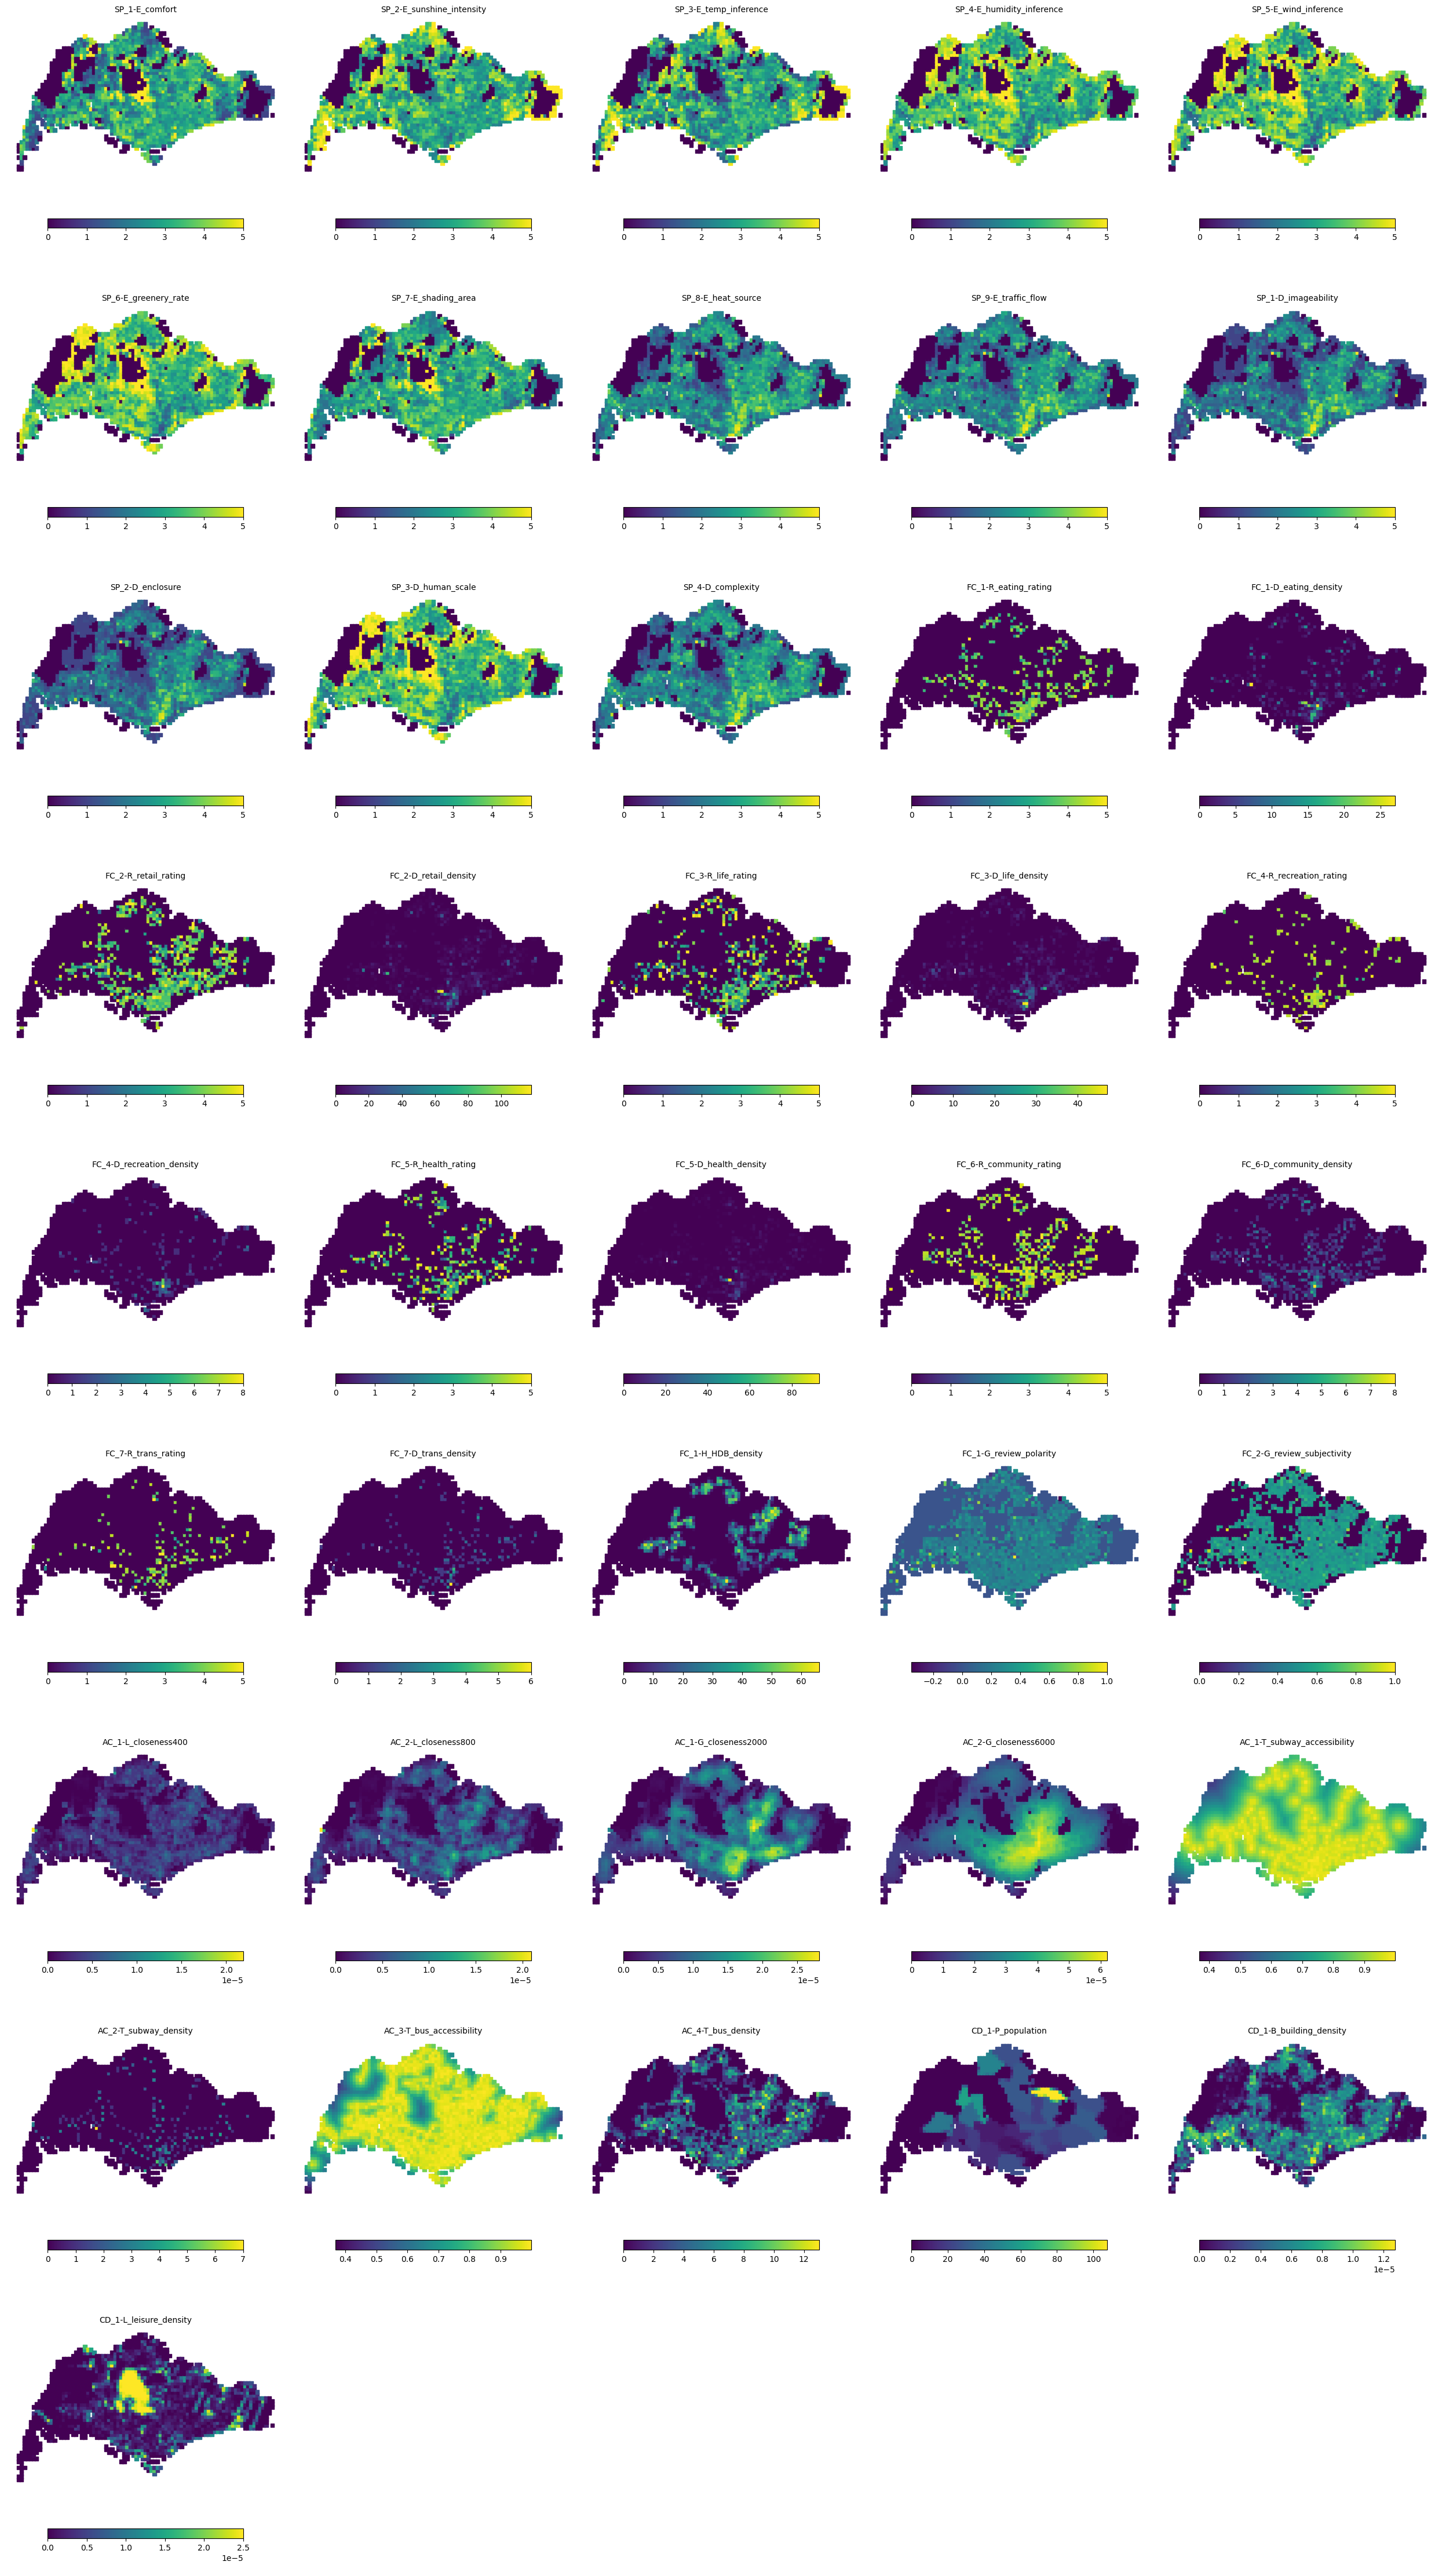

In [2]:
n_cols = 5
n_rows = int(len(columns_to_plot) / n_cols) + (len(columns_to_plot) % n_cols > 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))

for i, col in enumerate(columns_to_plot):
    ax = axes.flat[i]
    geo_gdf.plot(
        ax=ax,
        column=col,
        marker='s',          # use square marker
        markersize=22,       # consistent marker size
        legend=True,         # colorbar handled separately if needed
        cmap="viridis",
        legend_kwds={"orientation": 'horizontal', "shrink": 0.7}
    )
    ax.set_title(col, fontsize=10)
    ax.axis('off')

# Hide unused axes
for j in range(i+1, n_rows*n_cols):
    axes.flat[j].axis('off')

plt.tight_layout()
plt.show()